In [1]:
import time
start_time = time.time()

# Feature Importance and Explability in ML & QML

The first thing we need to do is load in all the modules and tools to build our classical models, generate our statistics, and create visualisations.

In [1]:
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.algorithms import VQC

from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from tqdm import tqdm

# Standard imports
import numpy as np
import pandas as pd
import time
import warnings

from sklearn.utils import resample
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
import shap
from alibi.explainers import ALE, plot_ale

/home/jc3988/.conda/envs/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
shap.initjs()

## The Iris Dataset

The Iris data set is well-known and commonly used data set used for classification. It contains four features (petal length, petal width, sepal (the green leaf under the petal) lenght, and sepal width), and four classes - Setosa, Versicolor, and Virginica

Text(0.5, 1.02, 'Pairplot of Iris Dataset')

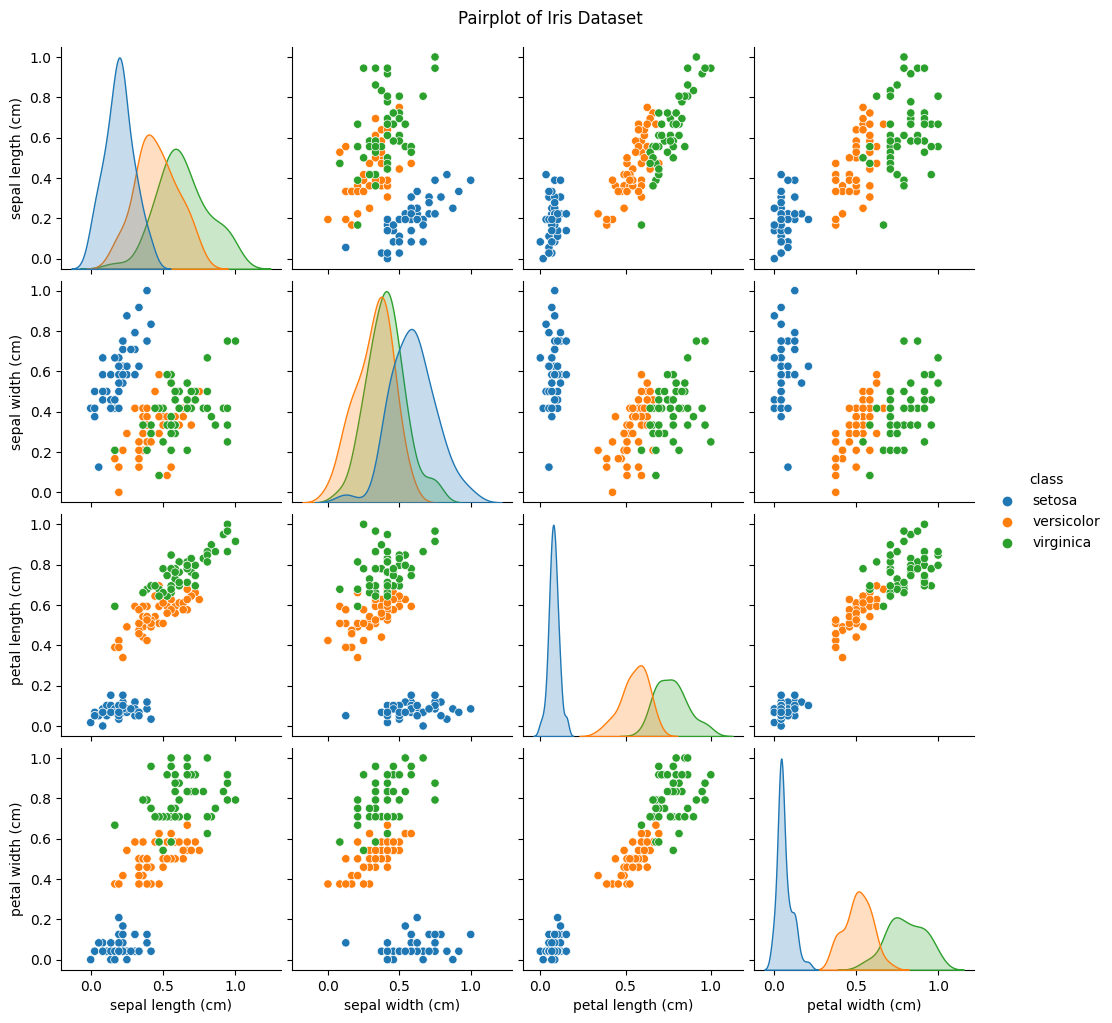

In [4]:
iris_data = load_iris()
features = iris_data.data
labels = iris_data.target
features = MinMaxScaler().fit_transform(features)
df = pd.DataFrame(features, columns=iris_data.feature_names)
df['class'] = [iris_data.target_names[label] for label in iris_data.target]


plot = sns.pairplot(df, hue='class', palette='tab10')
plt.savefig(f'Visuals/iris_pairplot.png')
plot.fig.suptitle("Pairplot of Iris Dataset", y=1.02)

We can see in the pairs plot above the setosa is easily seperated from the other two flowers, linearly seperable especially with respect to petal length.  

## Train and Load the models

We will be using a Support Vector Machine and Random Forest as out classical machine learning classifiers. Given the seperability of the data, these two methods perform extremely well with the Iris data. 

For our quantum models we will be using the Variational Quanum Classifier, and a Quantum Support Vector Classifier. To see how these are made please refer to [Iris VQC](iris_quantum_feature_importance.ipynb) and [Iris QSVC](iris_qsvm.ipynb) notebook.

For fitting and testing the models, we will be using an 80/20 split of the data. 

It is also worth noting that to properly compare with the quantum models, the data has been nomralised (this step allows the data to be mapped to the quantum state).

In [3]:
vqc = VQC.load('trained_model.model')

## Comparing the models

The most straightforward way to compare our models is to just check the accuracy of the models with the test. To best do this we use a technique called _bootstrapping_, this improves the trust of the accuracy score rather than doing simple check with the test subset, we can resample from this test multiple time, with replacement, to get a better understanding of how the model performs with the test data. 

In [4]:
def bootstrap_score(model, X_test, y_test, n_iterations=1000, random_state=4701):
    np.random.seed(random_state)  
    bootstrap_scores = []  
    ix = np.arange(len(X_test))  

    for i in tqdm(range(n_iterations), desc=f"Bootstrapping {model.__class__.__name__}"):
        boot = np.random.choice(ix, replace=True, size=len(X_test))  
        X_sample, y_sample = X_test[boot], y_test[boot]  
        score = model.score(X_sample, y_sample) 
        bootstrap_scores.append(score)  
    
    return bootstrap_scores

In [8]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

X = MinMaxScaler().fit_transform(X)

train_features, test_features, train_labels, test_labels = train_test_split(
        X, y, train_size=0.8, random_state=470)

In [9]:
# svc_scores = bootstrap_score(svc_model, test_features, test_labels, n_iterations = 1000, random_state = 4701)
# qsvc_scores = bootstrap_score(qsvc_model, test_features, test_labels, n_iterations = 1000, random_state = 4701)
# rf_scores = bootstrap_score(rf_model, test_features, test_labels, n_iterations = 1000, random_state = 4701)
vqc_scores = bootstrap_score(vqc, test_features, test_labels, n_iterations = 1000, random_state = 4701)

Bootstrapping VQC: 100%|██████████| 1000/1000 [03:31<00:00,  4.73it/s]


In [11]:
boot_scores_df = pd.DataFrame({
    'VQC': vqc_scores
})

boot_scores_df.to_csv('bootstrap_scores.csv', index=False)

In [12]:
models = [vqc]

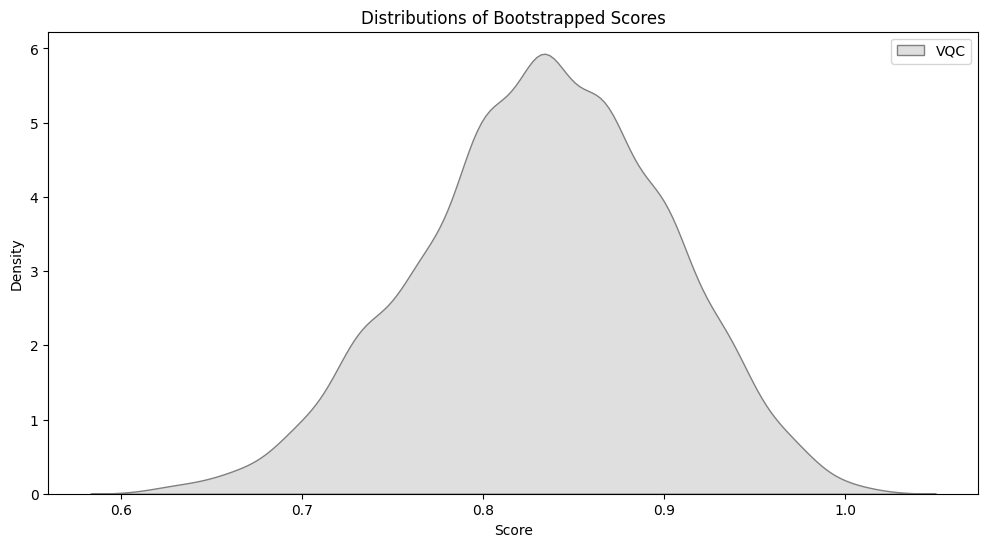

In [13]:
plt.figure(figsize=(12, 6))

sns.kdeplot(vqc_scores, fill=True, label ='VQC', color='grey', alpha = 0.25)

plt.title('Distributions of Bootstrapped Scores')
plt.xlabel('Score')
plt.ylabel('Density')
plt.savefig('Visuals/models/Model_accuracy_density_comparison.png')
plt.legend()
plt.show()

In [14]:
scores_by_model = {
    'VQC': vqc_scores,
}
df_list = [pd.DataFrame({'Score': scores, 'Model': model}) for model, scores in scores_by_model.items()]
df = pd.concat(df_list, ignore_index=True)

In [15]:
model_cols = {
    'VQC': 'grey',
} 

In [17]:
def predict_labels(model, X):
    return model.predict(X)

In [18]:
predictions = {}
confusion_matrices = {}
misclassified = []

In [19]:
for index, label in enumerate(test_labels):
    misclassified.append({
        'test_index': index, 
        'test_label': label, 
        'misclassified_by': [],
        'misclassified_as': {}  
    })

In [20]:
for model in models:
    model_name = type(model).__name__
    model_predictions = predict_labels(model, test_features)
    predictions[model_name] = model_predictions
    confusion_matrices[model_name] = confusion_matrix(test_labels, model_predictions)
    
    for index, (actual, predicted) in enumerate(zip(test_labels, model_predictions)):
        if actual != predicted:
            misclassified[index]['misclassified_by'].append(model_name)
            misclassified[index]['misclassified_as'][model_name] = predicted

In [21]:
misclassified = [m for m in misclassified if m['misclassified_by']]

In [22]:
misclassed = pd.DataFrame(misclassified)
misclassed

,test_index,test_label,misclassified_by,misclassified_as
0,8,1,[VQC],{'VQC': 2}
1,18,0,[VQC],{'VQC': 1}
2,24,0,[VQC],{'VQC': 1}
3,26,2,[VQC],{'VQC': 1}
4,29,0,[VQC],{'VQC': 1}


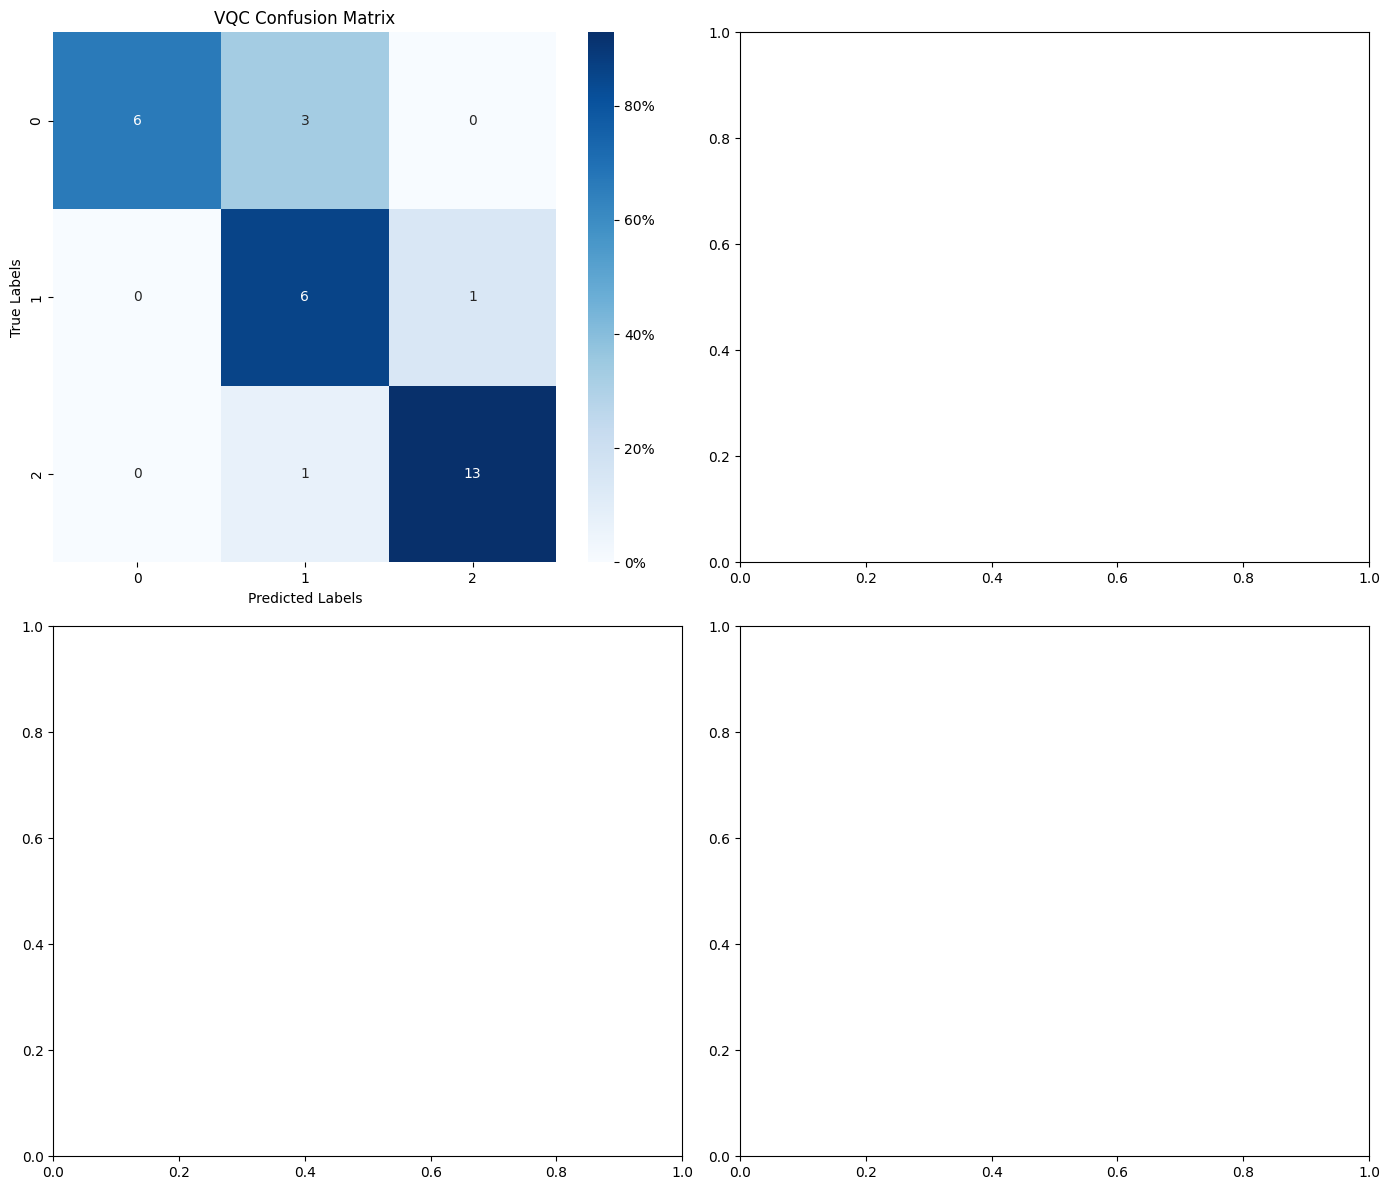

In [23]:
from matplotlib.ticker import PercentFormatter
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

cmaps = ["Blues"]#, "Reds", "Greens", "Greys"]

for i, (model_name, cm) in enumerate(confusion_matrices.items()):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cmap = cmaps[i % len(cmaps)]
    sns.heatmap(cm_normalized*100, annot=cm, ax=axes[i], cmap=cmap,cbar_kws={'format':PercentFormatter()})
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Labels')
    axes[i].set_ylabel('True Labels')

plt.tight_layout()
plt.savefig('Visuals/confusion_matrices_proportions.png')
plt.show()

## Feature Importance

Feature importance is an important tool in understanding a machine learning model. It is great way to get a generalization of why the model is acting the way it is, and what features are being assigned the most weight in making a decision. 

# SHAP

SHapley Additive exPlanations utilise game theory to explain the ouput of a model. 

In [38]:
def predict_fn(x):
    return vqc.predict(x).reshape(-1, 1)

In [39]:
vqc_explainer = shap.KernelExplainer(model=predict_fn, data=test_features)

In [40]:
vqc_explainer.explain(test_features)

array([[0.32222222],
       [0.03333333],
       [0.08333333],
       [0.29444444]])

## SHAP

In [55]:
vqc_shap_values = vqc_explainer.shap_values(test_features)

100%|██████████| 30/30 [01:35<00:00,  3.18s/it]


In [ ]:
np.save("vqc_shap_values.npy", vqc_shap_values)

### VQC

In [62]:
vqc_shap_values[4,].squeeze(1)

array([ 0.1       ,  0.32777778,  0.41111111, -0.10555556])

In [60]:
test_features[4]

array([0.5       , 0.25      , 0.77966102, 0.54166667])

In [63]:
shap.force_plot(vqc_explainer.expected_value, vqc_shap_values[4,].squeeze(1), test_features[4], feature_names=feature_names)

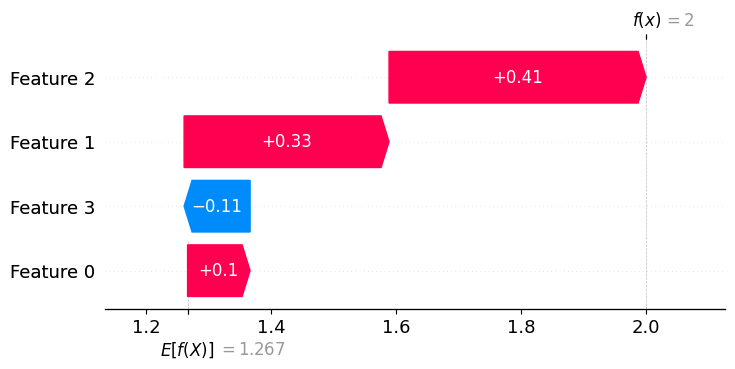

In [69]:
shap.plots._waterfall.waterfall_legacy(vqc_explainer.expected_value[0], vqc_shap_values[4].squeeze(1))

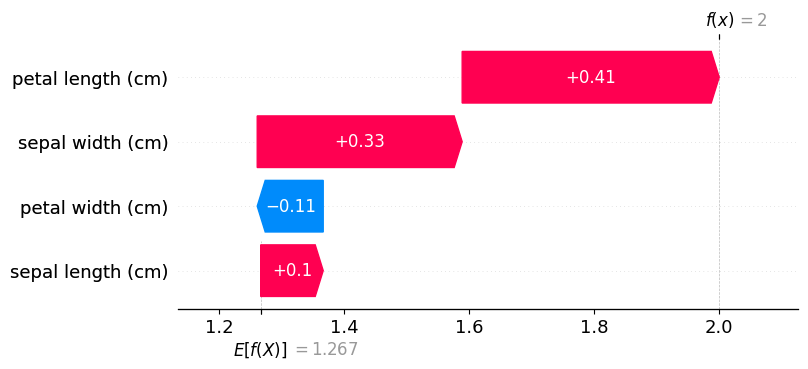

In [68]:
shap.plots._waterfall.waterfall_legacy(vqc_explainer.expected_value[0], vqc_shap_values[4].squeeze(1), feature_names=feature_names)